# Cross-validation EfficientNetB0 (from scratch, sans Transfer Learning)

Recherche d'hyperparamètres par **K-Fold stratifiée** sur `train + validation` (le `test` reste intouché pour l'évaluation finale).

Sortie : `cv_best_hyperparams.json` contenant les meilleurs `learning_rate` / `num_epochs` à recopier dans `01_train_efficientnet_b0.ipynb`.

Libraries imported successfully!

Augmentation pipelines created!

Loading dataset...


/home/gniax/projects/bellinna/Zoidberg2.0/venv/lib/python3.13/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)



  Dataset loaded!
  Train: 4705 images
  Validation: 522 images
  Test: 624 images

 Transforms applied!
 Images will be augmented on-the-fly when you load them


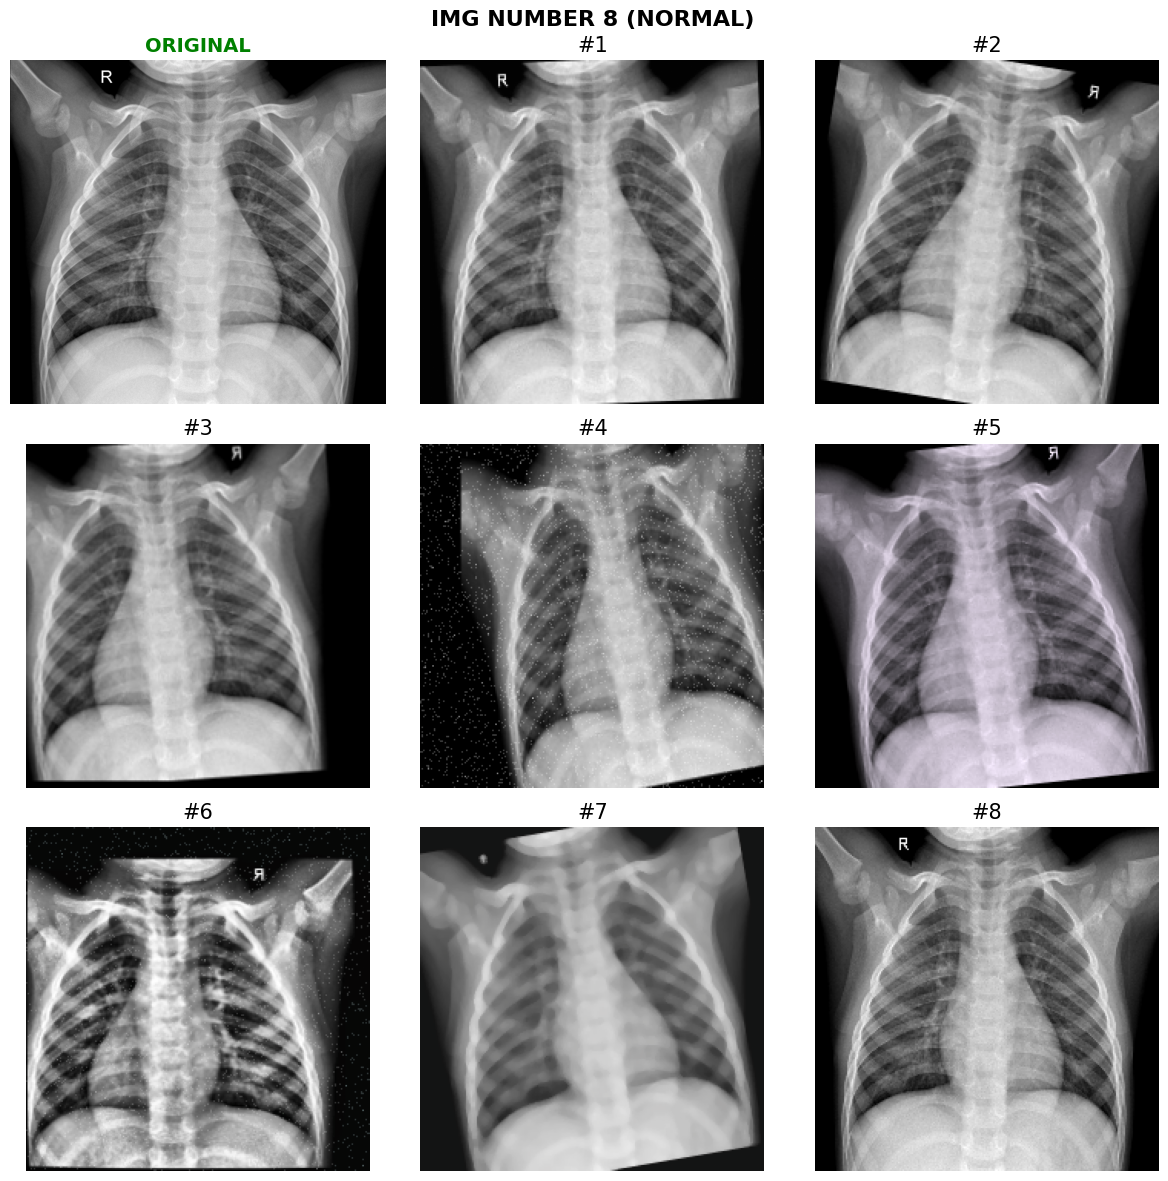


  DataLoaders ready!
  Batch size: 64
  Train batches: 74
  Val batches: 9
  Test batches: 10
Batch shape: torch.Size([64, 3, 224, 224])
Labels shape: torch.Size([64])

First 10 labels: [1, 2, 1, 1, 1, 0, 1, 0, 2, 1]
Label distribution: [18, 33, 13]


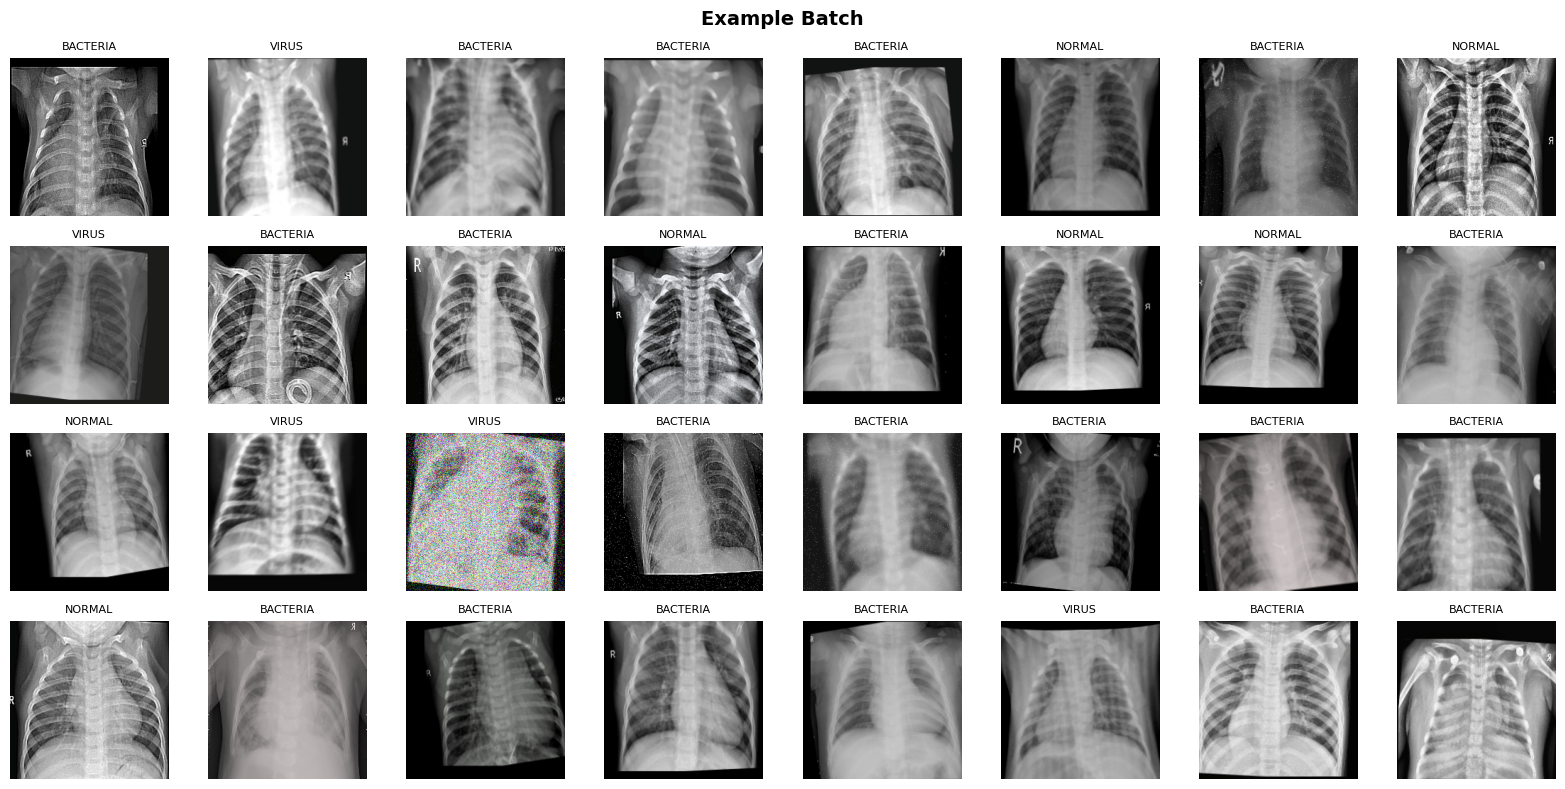

In [1]:
%run "../../preprocessing.ipynb"

In [2]:
import json, gc, time
from datetime import datetime
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision.models import efficientnet_b0
from sklearn.model_selection import StratifiedKFold
from datasets import concatenate_datasets
from tqdm.auto import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


## Configuration de la cross-validation

Sans transfer learning, il faut plus d'epochs et un learning rate plus élevé qu'en TL.

- `K_FOLDS = 3` : compromis temps / fiabilité.
- `MAX_EPOCHS = 20` : la courbe d'apprentissage est plus longue qu'en TL.
- Grid sur `learning_rate`.

In [3]:
K_FOLDS = 3
MAX_EPOCHS = 20
NUM_CLASSES = 3
LR_GRID = [5e-4, 1e-3, 3e-3]
SEED = 42

torch.manual_seed(SEED)
np.random.seed(SEED)

In [4]:
combined_raw = concatenate_datasets([dataset["train"], dataset["validation"]])
labels_all = np.array(combined_raw["label"])
print(f"Total train+val: {len(combined_raw)} | distribution: {np.bincount(labels_all).tolist()}")

combined_train_view = combined_raw.with_transform(apply_train_transforms)
combined_val_view   = combined_raw.with_transform(apply_val_test_transforms)

skf = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=SEED)
folds = list(skf.split(np.zeros(len(labels_all)), labels_all))
for i, (tr, va) in enumerate(folds):
    print(f"Fold {i+1}: train={len(tr)} | val={len(va)}")

Total train+val: 5227 | distribution: [1349, 2536, 1342]
Fold 1: train=3484 | val=1743
Fold 2: train=3485 | val=1742
Fold 3: train=3485 | val=1742


In [5]:
def build_model():
    # weights=None -> from scratch, pas de transfer learning
    m = efficientnet_b0(weights=None)
    in_f = m.classifier[1].in_features
    m.classifier[1] = nn.Linear(in_f, NUM_CLASSES)
    return m.to(device)

def make_loaders(train_idx, val_idx):
    tr = DataLoader(Subset(combined_train_view, train_idx.tolist()),
                    batch_size=BATCH_SIZE, shuffle=True,
                    num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available(),
                    persistent_workers=True)
    va = DataLoader(Subset(combined_val_view, val_idx.tolist()),
                    batch_size=BATCH_SIZE, shuffle=False,
                    num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available(),
                    persistent_workers=True)
    return tr, va

def train_one_fold(lr, train_loader, val_loader):
    model = build_model()
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    epoch_val_accs = []
    for epoch in range(1, MAX_EPOCHS + 1):
        model.train()
        for batch in train_loader:
            x = batch["image"].to(device, non_blocking=True)
            y = batch["label"].to(device, non_blocking=True)
            optimizer.zero_grad()
            loss = criterion(model(x), y)
            loss.backward()
            optimizer.step()

        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for batch in val_loader:
                x = batch["image"].to(device, non_blocking=True)
                y = batch["label"].to(device, non_blocking=True)
                preds = model(x).argmax(1)
                correct += (preds == y).sum().item()
                total += y.size(0)
        acc = correct / total
        epoch_val_accs.append(acc)
        print(f"    epoch {epoch:>2}/{MAX_EPOCHS} | val_acc={acc:.4f}")

    del model, optimizer, criterion
    gc.collect(); torch.cuda.empty_cache()
    return epoch_val_accs

In [6]:
results = []
t0 = time.time()

for lr in LR_GRID:
    print(f"\n=== lr = {lr} ===")
    accs_per_fold = []
    for fold_idx, (tr_idx, va_idx) in enumerate(folds):
        print(f"  fold {fold_idx+1}/{K_FOLDS}")
        train_loader, val_loader = make_loaders(tr_idx, va_idx)
        accs = train_one_fold(lr, train_loader, val_loader)
        accs_per_fold.append(accs)
        del train_loader, val_loader
        gc.collect()

    accs_arr = np.array(accs_per_fold)
    for ep in range(MAX_EPOCHS):
        col = accs_arr[:, ep]
        results.append({
            "learning_rate": lr,
            "num_epochs": ep + 1,
            "fold_val_accs": col.tolist(),
            "mean_val_acc": float(col.mean()),
            "std_val_acc": float(col.std()),
        })

elapsed = (time.time() - t0) / 60
print(f"\nCV terminée en {elapsed:.1f} min — {len(results)} combinaisons évaluées.")


=== lr = 0.0005 ===
  fold 1/3
    epoch  1/20 | val_acc=0.4848
    epoch  2/20 | val_acc=0.6529
    epoch  3/20 | val_acc=0.7068
    epoch  4/20 | val_acc=0.7131
    epoch  5/20 | val_acc=0.7688
    epoch  6/20 | val_acc=0.7384
    epoch  7/20 | val_acc=0.7240
    epoch  8/20 | val_acc=0.7877
    epoch  9/20 | val_acc=0.7745
    epoch 10/20 | val_acc=0.7757
    epoch 11/20 | val_acc=0.7946
    epoch 12/20 | val_acc=0.7912
    epoch 13/20 | val_acc=0.7923
    epoch 14/20 | val_acc=0.8026
    epoch 15/20 | val_acc=0.8021
    epoch 16/20 | val_acc=0.7992
    epoch 17/20 | val_acc=0.8003
    epoch 18/20 | val_acc=0.8078
    epoch 19/20 | val_acc=0.8049
    epoch 20/20 | val_acc=0.8130
  fold 2/3
    epoch  1/20 | val_acc=0.4851
    epoch  2/20 | val_acc=0.6378
    epoch  3/20 | val_acc=0.5057
    epoch  4/20 | val_acc=0.7118
    epoch  5/20 | val_acc=0.7342
    epoch  6/20 | val_acc=0.6866
    epoch  7/20 | val_acc=0.7371
    epoch  8/20 | val_acc=0.7761
    epoch  9/20 | val_acc=0.7910


In [7]:
best = max(results, key=lambda r: r["mean_val_acc"])

summary = {
    "model": "EfficientNetB0",
    "transfer_learning": False,
    "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "k_folds": K_FOLDS,
    "max_epochs": MAX_EPOCHS,
    "lr_grid": LR_GRID,
    "batch_size": BATCH_SIZE,
    "seed": SEED,
    "best_hyperparams": {
        "learning_rate": best["learning_rate"],
        "num_epochs": best["num_epochs"],
        "batch_size": BATCH_SIZE,
    },
    "best_mean_val_acc": best["mean_val_acc"],
    "best_std_val_acc": best["std_val_acc"],
    "all_results": results,
}

with open("cv_best_hyperparams.json", "w") as f:
    json.dump(summary, f, indent=2)

print("Meilleurs hyperparamètres :")
print(json.dumps(summary["best_hyperparams"], indent=2))
print(f"mean_val_acc = {best['mean_val_acc']:.4f} ± {best['std_val_acc']:.4f}")
print("\nFichier écrit : cv_best_hyperparams.json")

Meilleurs hyperparamètres :
{
  "learning_rate": 0.0005,
  "num_epochs": 20,
  "batch_size": 64
}
mean_val_acc = 0.8079 ± 0.0071

Fichier écrit : cv_best_hyperparams.json


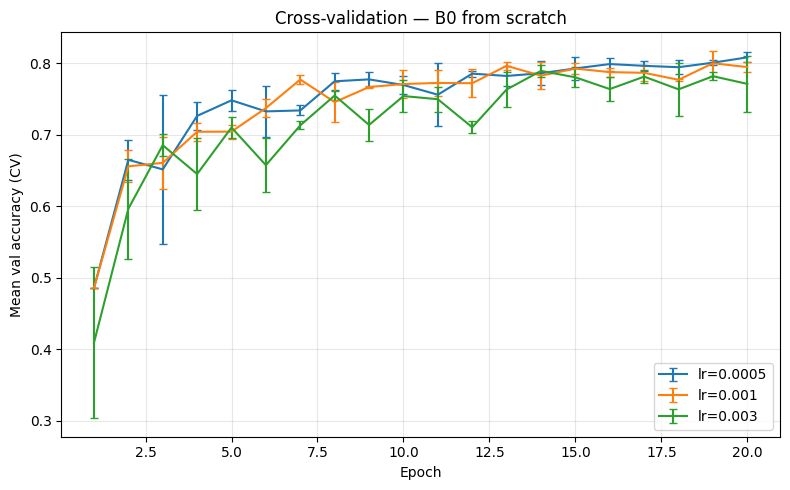

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
for lr in LR_GRID:
    means = [r["mean_val_acc"] for r in results if r["learning_rate"] == lr]
    stds  = [r["std_val_acc"] for r in results if r["learning_rate"] == lr]
    epochs = list(range(1, MAX_EPOCHS + 1))
    plt.errorbar(epochs, means, yerr=stds, label=f"lr={lr}", capsize=3)
plt.xlabel("Epoch")
plt.ylabel("Mean val accuracy (CV)")
plt.title("Cross-validation — B0 from scratch")
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()